# Занятие 25. Линейная регрессия

**Цель занятия:** научиться предсказывать **число** с помощью **линейной регрессии**,
> читать ошибки (**MAE**, **MSE**, **RMSE**) и **$R^2$**, честно делить данные на train / validation / test
> и замечать переобучение, регуляризацию, масштабирование и связанные признаки.

**Что будет:**
1. **Регрессия** — чем отличается от классификации и кластеризации;
2. **Прямая и ошибка** — $\hat y = wx + b$, остатки, MSE; как ищут лучшие веса;
3. **Метрики** — MAE, MSE, RMSE, $R^2$ и сравнение с baseline;
4. **Несколько признаков и кривые** — множественная регрессия и полиномиальные признаки;
5. **Сложность** — переобучение, Ridge / Lasso, масштабирование, выбросы, мультиколлинеарность.

> **Звёздочка в заголовке.** Разделы с `*` — повышенной сложности: можно пройти по диагонали при первом чтении.


## 1. Обучение с учителем и без

В задаче **кластеризации** мы работали с данными, в которых не было готовых ответов: алгоритм сам искал похожие объекты. Такие задачи называют **обучением без учителя** (*unsupervised learning*).

Гораздо чаще у нас есть **размеченные данные** — объекты, для которых правильный ответ уже известен. Кто-то (человек, прибор, история продаж) заранее его записал. Это **обучение с учителем** (*supervised learning*): «учитель» — как раз столбец с правильными ответами.

| | Есть готовые ответы? | Что делает алгоритм |
|---|---|---|
| Обучение без учителя | нет | ищет структуру: группы, похожие объекты |
| Обучение с учителем | да | учится повторять известные ответы на новых объектах |

Обучение с учителем делится на два больших случая по тому, **какого типа ответ** мы предсказываем. Их и сравним в следующем разделе.


## 2. Задача регрессии

**Регрессия** — предсказание числового ответа.

| Данные об объекте | Что предсказываем |
|---|---|
| площадь квартиры, район, этаж | цену в рублях |
| часы подготовки | балл за контрольную |
| температура и влажность | расход электричества |

Сравним знакомые задачи:

- **кластеризация:** готовых ответов нет, ищем похожие группы;
- **классификация:** ответ — категория, например «спам / не спам»;
- **регрессия:** ответ — число, например 73 балла.

Будем изучать связь между временем подготовки к ЕГЭ $x$ и результатом $y$.

| часы подготовки | балл |
|-----------------|------|
| 1 | 42 |
| 2 | 48 |
| 3 | 65 |
| 4 | 71 |
| 5 | 68 |
| 6 | 84 |
| 7 | 82 |
Это **учебный набор**: всего 7 учеников, числа придуманы. Для настоящей задачи такого объёма мало — в п. 8 мы увидим, к чему это приводит. Но на семи точках удобно всё пересчитать руками и увидеть каждую ошибку глазами.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.array([1, 2, 3, 4, 5, 6, 7], dtype=float)
scores = np.array([42, 48, 65, 71, 68, 84, 82], dtype=float)


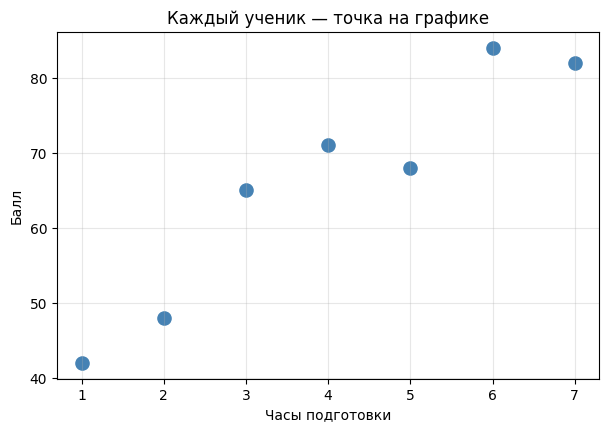


## 3. Линейная регрессия с одним признаком

График выше подсказывает, что балл зависит от часов подготовки почти **линейно**: все точки лежат близко к некоторой **прямой**.

Простейшая модель как раз и проводит прямую:

$$\hat y = wx + b$$

- $x$ — известный признак (у нас — часы подготовки);
- $\hat y$ (читается «игрек с крышкой») — прогноз модели;
- $w$ — **наклон**: на сколько меняется прогноз, если увеличить $x$ на 1;
- $b$ — **смещение**: прогноз при $x = 0$.

Обучить модель — значит подобрать всего два числа, $w$ и $b$. Сейчас мы поручим это `sklearn` и получим $w \approx 6{,}96$: каждый дополнительный час связан примерно с ростом прогноза на 7 баллов.

⚠️ Слово «связан» здесь не случайно. Это **связь в данных**, а не **доказательство причины**: сама по себе формула не доказывает, что именно часы вызвали рост. Зонтики часто встречаются рядом с лужами, но зонтики не создают лужи — причина и того, и другого — дождь.


In [3]:
from sklearn.linear_model import LinearRegression

# sklearn ожидает таблицу признаков (строки — объекты, столбцы — признаки),
# а не одномерный массив. reshape(-1, 1) делает из 7 чисел таблицу 7×1;
# -1 означает «посчитай это число сам».
X = hours.reshape(-1, 1)
print('Было (одномерный массив):', hours)
print('Стало (таблица 7×1):')
print(X)

model = LinearRegression()
model.fit(X, scores)

w = model.coef_[0]
b = model.intercept_
print(f'\nФормула: балл ≈ {w:.2f} · часы + {b:.2f}')
print(f'Прогноз для 4.5 часов: {model.predict([[4.5]])[0]:.1f}')
print(f'Прогноз для 8 часов:   {model.predict([[8]])[0]:.1f}  <-- осторожно!')
print('\n8 часов лежит ЗА пределами того, что модель видела (она знает только 1...7).')
print('Такой прогноз называют экстраполяцией, и доверять ему нельзя: см. п. 10.')


Было (одномерный массив): [1. 2. 3. 4. 5. 6. 7.]
Стало (таблица 7×1):
[[1.]
 [2.]
 [3.]
 [4.]
 [5.]
 [6.]
 [7.]]

Формула: балл ≈ 6.96 · часы + 37.86
Прогноз для 4.5 часов: 69.2
Прогноз для 8 часов:   93.6  <-- осторожно!

8 часов лежит ЗА пределами того, что модель видела (она знает только 1...7).
Такой прогноз называют экстраполяцией, и доверять ему нельзя: см. п. 10.


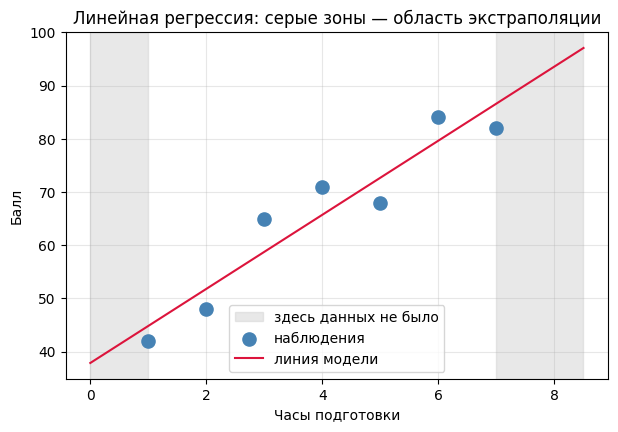

In [4]:
grid = np.linspace(0, 8.5, 100)

plt.figure(figsize=(7, 4.5))
plt.axvspan(0, 1, color='lightgray', alpha=0.5)
plt.axvspan(7, 8.5, color='lightgray', alpha=0.5, label='здесь данных не было')
plt.scatter(hours, scores, s=90, color='steelblue', zorder=3, label='наблюдения')
plt.plot(grid, model.predict(grid.reshape(-1, 1)), color='crimson', label='линия модели')
plt.xlabel('Часы подготовки')
plt.ylabel('Балл')
plt.title('Линейная регрессия: серые зоны — область экстраполяции')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 4. Ошибка модели и MSE

Мы провели какую-то прямую. Теперь нужно научиться считать, **насколько сильно мы промахнулись**, — чтобы потом эту ошибку минимизировать.

Для каждой точки есть **остаток** (ошибка):

$$e_i = y_i - \hat y_i.$$

У одних точек остаток положительный (модель занизила), у других — отрицательный (завысила). Просто сложить их нельзя: плюсы и минусы погасят друг друга, и среднее может оказаться нулём даже у совершенно негодной модели. Поэтому ошибки возводят в квадрат и усредняют. Так получается **MSE** (*Mean Squared Error* — средняя квадратичная ошибка):

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2.$$

Квадрат делает так, что **большие промахи весят непропорционально много**:

| Ошибка модели | Вклад в MSE |
|---|---|
| 1 балл | 1 |
| 2 балла | 4 |
| 5 баллов | 25 |
| 10 баллов | 100 |
| 20 баллов | 400 |

Промах в 20 баллов вдвое больше промаха в 10, но в MSE он весит вчетверо больше. Именно поэтому **две ошибки по 10 баллов** дают вклад $100 + 100 = 200$, а **одна ошибка в 20 баллов** — сразу $400$. Для MSE один крупный провал хуже, чем два средних.

*Можно было бы брать не квадраты, а модули ошибок. Но у функции с модулем в нуле «угол», и обычная производная там не определена. Оптимизировать такие функции всё равно умеют, однако для первого знакомства квадраты удобнее.*


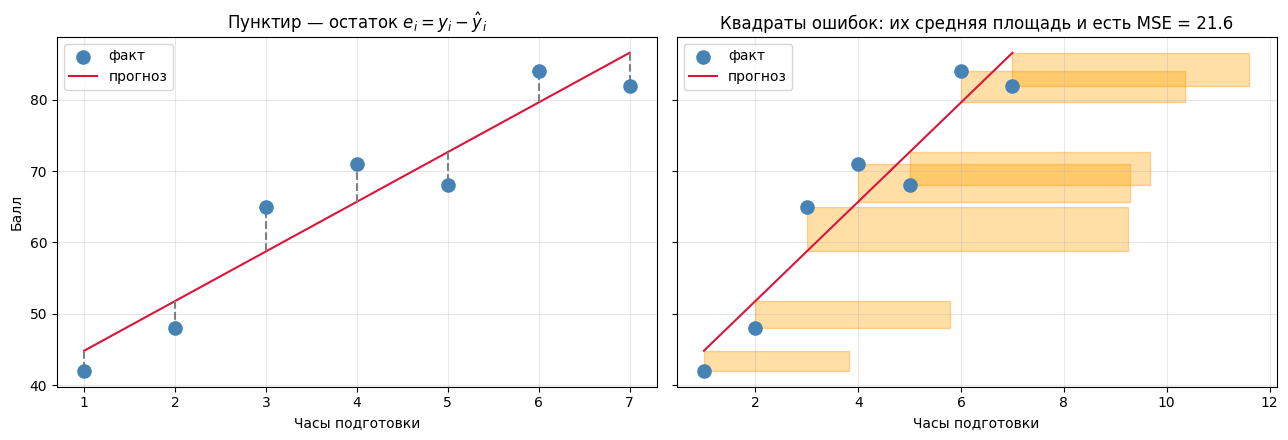

Самый большой остаток: +6.3 балла,
и именно он даёт самый большой квадрат: 39.1


In [5]:
pred = model.predict(X)
residuals = scores - pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

# Слева — сами остатки.
axes[0].scatter(hours, scores, s=90, color='steelblue', zorder=3, label='факт')
axes[0].plot(hours, pred, color='crimson', label='прогноз')
for x, y, y_hat in zip(hours, scores, pred):
    axes[0].plot([x, x], [y_hat, y], color='gray', linestyle='--')
axes[0].set_title('Пунктир — остаток $e_i = y_i - \\hat y_i$')

# Справа — те же остатки как СТОРОНЫ квадратов: MSE складывает их площади.
axes[1].scatter(hours, scores, s=90, color='steelblue', zorder=3, label='факт')
axes[1].plot(hours, pred, color='crimson', label='прогноз')
for x, y, y_hat in zip(hours, scores, pred):
    side = y - y_hat
    axes[1].add_patch(plt.Rectangle((x, min(y, y_hat)), abs(side), abs(side),
                                    facecolor='orange', alpha=0.35, edgecolor='darkorange'))
axes[1].set_title(f'Квадраты ошибок: их средняя площадь и есть MSE = {np.mean(residuals**2):.1f}')

for ax in axes:
    ax.set_xlabel('Часы подготовки')
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel('Балл')
plt.tight_layout()
plt.show()

print(f'Самый большой остаток: {residuals[np.abs(residuals).argmax()]:+.1f} балла,')
print(f'и именно он даёт самый большой квадрат: {residuals[np.abs(residuals).argmax()]**2:.1f}')


## 5. Как находится лучшая прямая *

Алгоритм подбирает $w$ и $b$, чтобы MSE была минимальна. Представьте холмистую поверхность: высота — ошибка, координаты — значения $w$ и $b$. Нужно попасть в самую низкую точку.

Есть два основных пути.

1. **Прямое решение.** Если вы уже знакомы с производными, с их помощью можно записать условия минимума и решить систему уравнений. Для одного признака получается
   $$w=\frac{\sum(x_i-\bar x)(y_i-\bar y)}{\sum(x_i-\bar x)^2},\qquad b=\bar y-w\bar x,$$
   где через $\bar x$ и $\bar y$ обозначены средние арифметические. 
   
Линейная регрессия - один из немногих алгоритмов машинного обучения, где решение можно посчитать "по формуле" (хотя и здесь есть свои ограничения). В большинстве способов приходится делать много шагов, последовательно уменьшая ошибку. 

2. **Градиентный спуск.** Начать с произвольных коэффициентов $w$ и $b$ и много раз делать маленький шаг в сторону уменьшения ошибки.

Ниже — вид сверху на «ландшафт ошибки». Замкнутые линии соединяют точки с одинаковой MSE, как горизонтали на географической карте. Красные точки показывают последовательные шаги к минимуму.

<svg width="620" height="310" viewBox="0 0 620 310" xmlns="http://www.w3.org/2000/svg" role="img" aria-label="Градиентный спуск движется по линиям уровня MSE к минимуму">
  <defs>
    <marker id="arrow" markerWidth="9" markerHeight="9" refX="7" refY="3" orient="auto"><path d="M0,0 L0,6 L8,3 z" fill="#c62828"/></marker>
  </defs>
  <rect x="1" y="1" width="618" height="308" rx="12" fill="#fafafa" stroke="#dddddd"/>
  <text x="310" y="27" text-anchor="middle" font-size="17" font-family="sans-serif">Вид сверху на поверхность MSE</text>
  <ellipse cx="330" cy="170" rx="245" ry="115" fill="#e8f1fa" stroke="#6b9ac4" stroke-width="1"/>
  <ellipse cx="330" cy="170" rx="175" ry="80" fill="#d7e8f7" stroke="#5689b4" stroke-width="1"/>
  <ellipse cx="330" cy="170" rx="105" ry="46" fill="#c3ddf2" stroke="#3f78a8" stroke-width="1"/>
  <ellipse cx="330" cy="170" rx="37" ry="17" fill="#a9d0ed" stroke="#245f91" stroke-width="1"/>
  <circle cx="330" cy="170" r="6" fill="#174d78"/>
  <text x="339" y="160" font-size="13" font-family="sans-serif">минимум MSE</text>
  <polyline points="105,83 168,109 220,128 263,145 297,157 320,166" fill="none" stroke="#c62828" stroke-width="2" marker-mid="url(#arrow)" marker-end="url(#arrow)"/>
  <g fill="#c62828"><circle cx="105" cy="83" r="6"/><circle cx="168" cy="109" r="6"/><circle cx="220" cy="128" r="6"/><circle cx="263" cy="145" r="6"/><circle cx="297" cy="157" r="6"/><circle cx="320" cy="166" r="6"/></g>
  <text x="62" y="69" font-size="13" font-family="sans-serif" fill="#c62828">старт</text>
  <line x1="65" y1="275" x2="575" y2="275" stroke="#555" marker-end="url(#arrow)"/><text x="580" y="281" font-size="14" font-family="sans-serif">w</text>
  <line x1="65" y1="275" x2="65" y2="43" stroke="#555" marker-end="url(#arrow)"/><text x="54" y="42" font-size="14" font-family="sans-serif">b</text>
</svg>

Прямое решение средствами линейной алгебры быстро работает *для небольших таблиц*. Градиентный спуск удобнее для огромных данных и сложных моделей, но требует подобрать размер шага и число итераций.

**А что делает sklearn?** В библиотеке есть две модели для нашей задачи.

- `LinearRegression` решает **задачу наименьших квадратов** (англ. *OLS, Ordinary Least Squares* — «обычные наименьшие квадраты») прямым методом линейной алгебры. Подходит, когда признаков и объектов не слишком много.
- `SGDRegressor` (*Stochastic Gradient Descent* — **стохастический градиентный спуск**) идёт к минимуму шагами, причём на каждом шаге смотрит не на все объекты сразу, а на небольшую случайную порцию. Поэтому он выигрывает на очень больших данных.

Дальше в занятии мы пользуемся `LinearRegression`.


In [6]:
# Проверим: даёт ли формула ровно то же, что sklearn?
x_mean, y_mean = hours.mean(), scores.mean()
w_manual = np.sum((hours - x_mean) * (scores - y_mean)) / np.sum((hours - x_mean)**2)
b_manual = y_mean - w_manual * x_mean

print(f'Вручную по формуле: w = {w_manual:.4f}, b = {b_manual:.4f}')
print(f'Что дал sklearn:    w = {w:.4f}, b = {b:.4f}')

assert np.isclose(w_manual, w) and np.isclose(b_manual, b), 'Формула и sklearn разошлись!'
print('\nСовпало до последнего знака: sklearn решает ту же самую задачу, просто быстрее.')


Вручную по формуле: w = 6.9643, b = 37.8571
Что дал sklearn:    w = 6.9643, b = 37.8571

Совпало до последнего знака: sklearn решает ту же самую задачу, просто быстрее.


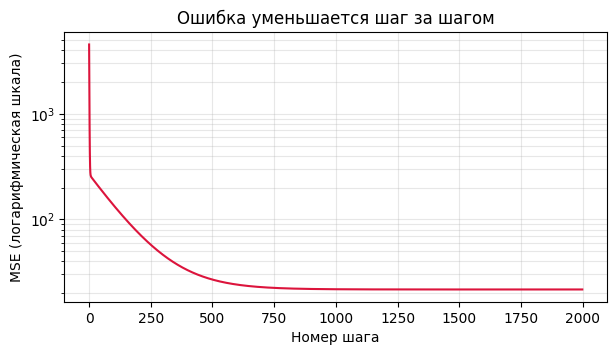


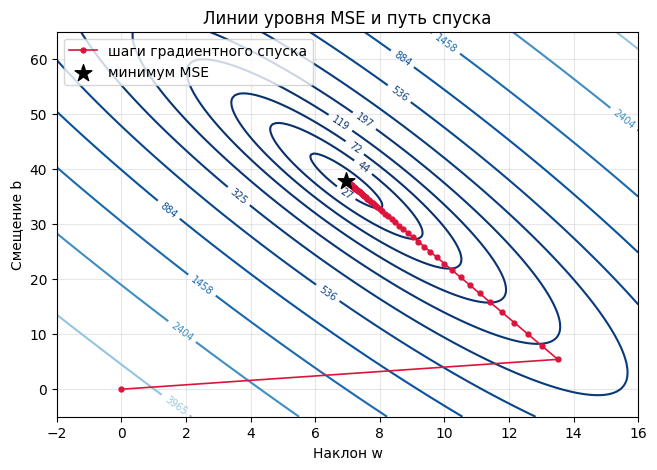


## 6. Метрики качества: MAE, MSE и RMSE

MSE может играть две роли: быть **функцией потерь** (*loss function*) во время обучения и **метрикой** после обучения. Формула одна и та же, разница только в том, как мы её используем: в первом случае мы её минимизируем, во втором — просто смотрим на число.

Кроме MSE есть ещё две привычные меры ошибки:

| Метрика | Полное название | Формула | Особенность |
|---|---|---|---|
| **MAE** | *Mean Absolute Error* — средняя абсолютная ошибка | $\frac1n\sum\lvert y_i-\hat y_i\rvert$ | измеряется в тех же единицах, что и ответ (в баллах); мягче относится к редким большим промахам |
| **MSE** | *Mean Squared Error* — средняя квадратичная ошибка | $\frac1n\sum(y_i-\hat y_i)^2$ | сильно штрафует большие промахи; измеряется в **квадратных** единицах (балл²) |
| **RMSE** | *Root Mean Squared Error* — корень из средней квадратичной ошибки | $\sqrt{MSE}$ | так же чувствительна к большим промахам, но снова в баллах, а не в балл² |

Чем они отличаются на деле? Возьмём две модели, каждая ошиблась «в сумме на 20 баллов»:

| | Ошибки | MAE | MSE |
|---|---|---|---|
| Модель А | 10 и 10 | $(10+10)/2 = 10$ | $(100+100)/2 = 100$ |
| Модель Б | 20 и 0 | $(20+0)/2 = 10$ | $(400+0)/2 = 200$ |

**MAE не видит разницы, MSE — видит, и вдвое.** Отсюда правило выбора: если один крупный провал опаснее двух средних (например, ошибка прогноза лекарства или нагрузки на мост) — берите MSE или RMSE. Если важна типичная ошибка в понятных единицах — берите MAE. Универсально «лучшей» метрики нет, её выбирает задача.


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Пока это учебный расчёт на тех же данных, по которым модель обучалась.
mae = mean_absolute_error(scores, pred)
mse = mean_squared_error(scores, pred)
rmse = np.sqrt(mse)     # в старых версиях sklearn был параметр squared=False, теперь берём корень сами

print('Метрики на обучающих данных:')
print(f'MAE  = {mae:.2f} балла')
print(f'MSE  = {mse:.2f} балла²   <-- квадратные баллы, «на глаз» не читаются')
print(f'RMSE = {rmse:.2f} балла   <-- то же самое, но снова в баллах')
print()
print(f'Для сравнения: средний балл в наборе {scores.mean():.1f},')
print(f'а разброс баллов — от {scores.min():.0f} до {scores.max():.0f}.')
print(f'То есть модель типично промахивается примерно на {mae:.0f} балла при размахе {scores.max()-scores.min():.0f}.')
print('\nВывод: модель близко описывает известные точки — но это ещё не проверка на *новых* учениках.')


Метрики на обучающих данных:
MAE  = 4.54 балла
MSE  = 21.63 балла²   <-- квадратные баллы, «на глаз» не читаются
RMSE = 4.65 балла   <-- то же самое, но снова в баллах

Для сравнения: средний балл в наборе 65.7,
а разброс баллов — от 42 до 84.
То есть модель типично промахивается примерно на 5 балла при размахе 42.

Вывод: модель близко описывает известные точки — но это ещё не проверка на *новых* учениках.


## 7. Насколько мы лучше самого простого прогноза: $R^2$

Прежде чем строить линейную регрессию, ответим на неудобный вопрос: **а с чем мы вообще сравниваем?** Проведём *горизонтальную* прямую, то есть для любого $x$ будем выдавать одно и то же число. Такое нарочито простое решение, с которым сравнивают все остальные, называют **baseline** (читается «бейзлайн», по-русски — базовое, или эталонное, решение).

Для MSE лучший константный baseline — это **среднее значение** $\bar y$: никакое другое одно число не даст меньшую сумму квадратов.

Теперь можно спросить: какую долю ошибки baseline модель сумела убрать? Это и есть **коэффициент детерминации** $R^2$ (читается «эр квадрат»):

$$R^2 = 1-\frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2}.$$

Сверху — ошибка нашей модели, снизу — ошибка baseline. Отсюда шкала:

- $R^2=1$ — прогнозы идеальны на этом наборе;
- $R^2=0$ — модель ровно не лучше, чем «всегда говорить среднее»;
- $R^2<0$ — модель **хуже** baseline.

Отрицательный $R^2$ вполне возможен **на новых тестовых данных**, которых модель не видела. А вот на обучающих данных обычная линейная регрессия со свободным членом $b$ подбирает коэффициенты не хуже среднего, поэтому там её $R^2$ всегда неотрицателен.

Три предостережения:

1. Универсальной границы «хорошего» $R^2$ нет: в одной области $0{,}5$ — успех, в другой $0{,}95$ — мало.
2. $R^2$ **не означает «процент правильных ответов»**.
3. При добавлении признаков обучающий $R^2$ может расти, даже если новый признак бесполезен. Есть скорректированный $R^2$ (*adjusted $R^2$*) со штрафом за число признаков, но окончательную проверку всё равно проводят на отдельных тестовых данных.


Сравнение на обучающих данных:
MSE baseline: 215.63
MSE модели:   21.63

Откуда берётся R²:
  сумма квадратов ошибок baseline = 1509.4
  сумма квадратов ошибок модели   = 151.4
  R² = 1 - 151.4 / 1509.4 = 0.900
  проверка через sklearn: 0.900

Вывод: модель убрала 90% ошибки baseline на известных точках.
Но обобщение на новых учениках проверим отдельно.


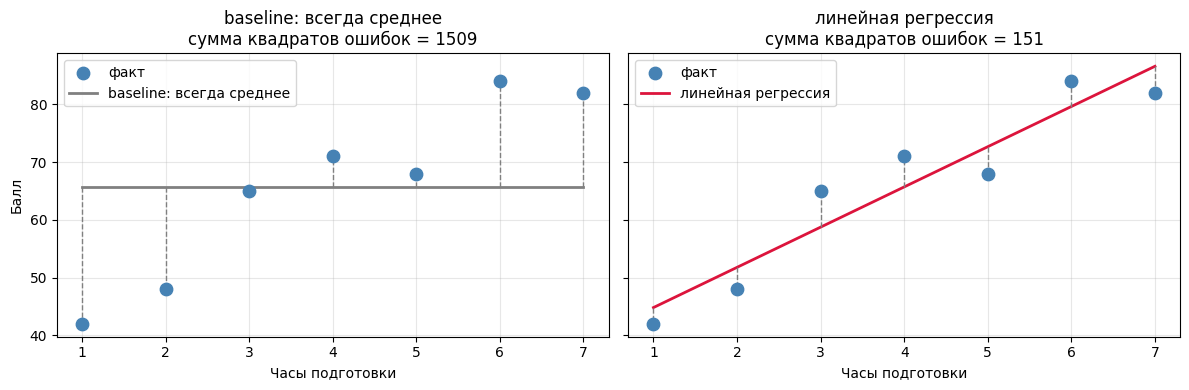

In [10]:
baseline = np.full_like(scores, scores.mean())

ss_baseline = np.sum((scores - baseline)**2)
ss_model = np.sum((scores - pred)**2)

print('Сравнение на обучающих данных:')
print(f'MSE baseline: {mean_squared_error(scores, baseline):.2f}')
print(f'MSE модели:   {mean_squared_error(scores, pred):.2f}')
print()
print('Откуда берётся R²:')
print(f'  сумма квадратов ошибок baseline = {ss_baseline:.1f}')
print(f'  сумма квадратов ошибок модели   = {ss_model:.1f}')
print(f'  R² = 1 - {ss_model:.1f} / {ss_baseline:.1f} = {1 - ss_model/ss_baseline:.3f}')
print(f'  проверка через sklearn: {r2_score(scores, pred):.3f}')
print('\nВывод: модель убрала 90% ошибки baseline на известных точках.')
print('Но обобщение на новых учениках проверим отдельно.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, y_hat, name, color in [
    (axes[0], baseline, 'baseline: всегда среднее', 'gray'),
    (axes[1], pred, 'линейная регрессия', 'crimson'),
]:
    ax.scatter(hours, scores, s=80, color='steelblue', zorder=3, label='факт')
    ax.plot(hours, y_hat, color=color, linewidth=2, label=name)
    for x_, y_, yh_ in zip(hours, scores, y_hat):
        ax.plot([x_, x_], [yh_, y_], color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{name}\nсумма квадратов ошибок = {np.sum((scores - y_hat)**2):.0f}')
    ax.set_xlabel('Часы подготовки')
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel('Балл')
plt.tight_layout()
plt.show()


## 8. Train / validation / test для регрессии

Оценивать модель на тех же примерах, по которым она училась, нечестно: это как принести на контрольную заранее решённые задачи. Поэтому данные делят на три части **до** начала работы:

| Часть | Как читается | Зачем нужна | Сколько раз используется |
|---|---|---|---|
| **train** | «трейн», обучающая | модель подбирает по ней $w$ и $b$ | много |
| **validation** | «валидация», проверочная | по ней выбираем признаки, регуляризацию и другие настройки | много |
| **test** | «тест», тестовая | одна-единственная финальная проверка выбранного решения | **ровно один раз** |

Типичное деление — примерно 60 / 20 / 20 процентов, но точные доли зависят от размера данных.

Почему test используют **только один раз**? Как только вы посмотрели на test и что-то из-за него поменяли, он перестал быть «новыми данными»: вы уже подстроились под него, пусть и через собственную голову. Это разновидность **утечки данных** (*data leakage*) — когда информация, которой в момент обучения быть не должно, всё-таки просачивается в модель.

> **Кросс-валидация** — приём для случая, когда данных мало и жалко отрезать целую часть под validation. Данные режут на $k$ равных кусков и повторяют обучение $k$ раз: каждый раз один кусок работает проверочным, остальные — обучающими. Итог — среднее по $k$ прогонам, оно устойчивее одной случайной разбивки.

Пример ниже сравнивает train и test для одной заранее зафиксированной модели: мы ничего не выбираем, только смотрим на разрыв.


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, scores, test_size=2, random_state=42
)
check_model = LinearRegression().fit(X_train, y_train)

train_mae = mean_absolute_error(y_train, check_model.predict(X_train))
test_mae = mean_absolute_error(y_test, check_model.predict(X_test))

print(f'В train попали часы: {np.sort(X_train.ravel())}')
print(f'В test  попали часы: {np.sort(X_test.ravel())}')
print()
print(f'MAE на обучении: {train_mae:.2f}')
print(f'MAE на тесте:    {test_mae:.2f}')
print()
for x_, y_true, y_hat in zip(X_test.ravel(), y_test, check_model.predict(X_test)):
    print(f'  {x_:.0f} ч: модель говорит {y_hat:.1f}, на самом деле {y_true:.0f}')

print('\nВывод: тестовая ошибка в четыре раза больше обучающей — но не только из-за «невезения».')
print('Смотрите, ЧТО попало в test: самые маленькие значения часов, 1 и 2.')
print('Модель училась на диапазоне 3...7 и вынуждена экстраполировать вниз — вот она и завышает.')
print('При семи объектах одна случайная разбивка ничего не доказывает: нужны либо')
print('больше данных, либо кросс-валидация.')


В train попали часы: [3. 4. 5. 6. 7.]
В test  попали часы: [1. 2.]

MAE на обучении: 2.96
MAE на тесте:    12.55

  1 ч: модель говорит 55.2, на самом деле 42
  2 ч: модель говорит 59.9, на самом деле 48

Вывод: тестовая ошибка в четыре раза больше обучающей — но не только из-за «невезения».
Смотрите, ЧТО попало в test: самые маленькие значения часов, 1 и 2.
Модель училась на диапазоне 3...7 и вынуждена экстраполировать вниз — вот она и завышает.
При семи объектах одна случайная разбивка ничего не доказывает: нужны либо
больше данных, либо кросс-валидация.


## 9. Множественная линейная регрессия

В жизни признаков почти всегда несколько:

$$\hat y=w_1x_1+w_2x_2+\ldots+w_px_p+b.$$

Цену квартиры естественно оценивать сразу по площади, расстоянию до центра и этажу. У каждого признака — свой вес $w_j$; все произведения складываются, к сумме добавляется смещение $b$. Модель по-прежнему **линейна по коэффициентам**: ничего сложнее умножения и сложения внутри неё нет.

Как читать вес $w_j$: «если остальные признаки не меняются, а $x_j$ вырос на 1, прогноз изменится на $w_j$». Это осторожная формулировка, а не доказательство причинности.

⚠️ **Важная ловушка.** Веса разных признаков **нельзя сравнивать между собой напрямую**, потому что они измеряются в разных единицах. Вес «за 1 м²» и вес «за 1 км» — это как сравнивать цену за грамм с ценой за тонну. Через одну ячейку мы на это наступим, а в п. 14 разберём, как чинить.


In [12]:
import pandas as pd
from sklearn.linear_model import LinearRegression

apartments = pd.DataFrame({
    'площадь': [30, 40, 50, 60, 70, 80],
    'до_центра_км': [2, 8, 5, 10, 4, 12],
    'цена_млн': [7.1, 6.9, 9.8, 9.5, 13.5, 12.2]
})
multi = LinearRegression().fit(apartments[['площадь', 'до_центра_км']], apartments['цена_млн'])
area_weight, distance_weight = multi.coef_
print(f'Вес площади: {area_weight:.3f} млн рублей за 1 м²')
print(f'Вес расстояния: {distance_weight:.3f} млн рублей за 1 км')
print(f'Смещение: {multi.intercept_:.3f}')
print('Вывод: при неизменном втором признаке площадь повышает прогноз,')
print('а дополнительный километр до центра — понижает. Это связь, а не доказанная причина.')
print()
print(f'А теперь ловушка: |{distance_weight:.3f}| больше, чем {area_weight:.3f}.')
print('Значит ли это, что расстояние важнее площади? НЕТ.')
print('Один вес — «за 1 квадратный метр», другой — «за 1 километр»; это разные единицы,')
print('и сравнивать их между собой бессмысленно. Как сделать веса сравнимыми — в п. 14.')


Вес площади: 0.174 млн рублей за 1 м²
Вес расстояния: -0.366 млн рублей за 1 км
Смещение: 2.790
Вывод: при неизменном втором признаке площадь повышает прогноз,
а дополнительный километр до центра — понижает. Это связь, а не доказанная причина.

А теперь ловушка: |-0.366| больше, чем 0.174.
Значит ли это, что расстояние важнее площади? НЕТ.
Один вес — «за 1 квадратный метр», другой — «за 1 километр»; это разные единицы,
и сравнивать их между собой бессмысленно. Как сделать веса сравнимыми — в п. 14.


## 10. Когда линейная модель не работает

Прямая — очень жёсткая форма. Вот четыре ситуации, где она подводит.

| Что в данных | Пример | Что делает прямая |
|---|---|---|
| **Изгибы и волны** | площадь круга от радиуса | режет дугу пополам: недооценивает края, переоценивает середину |
| **Резкие пороги** | скидка появляется от 5000 ₽ и ни рублём раньше | сглаживает ступеньку в пологий склон |
| **Взаимодействие признаков** | удобрение помогает, только если есть полив | не может сказать «эффект одного зависит от другого» — у неё каждый вес работает сам по себе |
| **Экстраполяция** | прогноз на 20 часов подготовки, когда видели только 1…7 | уверенно продолжает прямую туда, где данных не было (см. яч. с прогнозом на 8 часов) |

Как это **заметить**, а не угадать? Построить **график остатков**: по горизонтали — признак, по вертикали — остаток $e_i = y_i - \hat y_i$. Если модель поймала закономерность, остатки выглядят как бесформенное случайное облако вокруг нуля. Если в облаке проступает дуга, волна или ступенька — модель что-то пропустила, и это «что-то» осталось в ошибках.

Проверим на данных, где настоящая зависимость — парабола.


R² прямой на этих данных: 0.002
Почти ноль! То есть прямая здесь не лучше, чем «всегда говорить среднее».


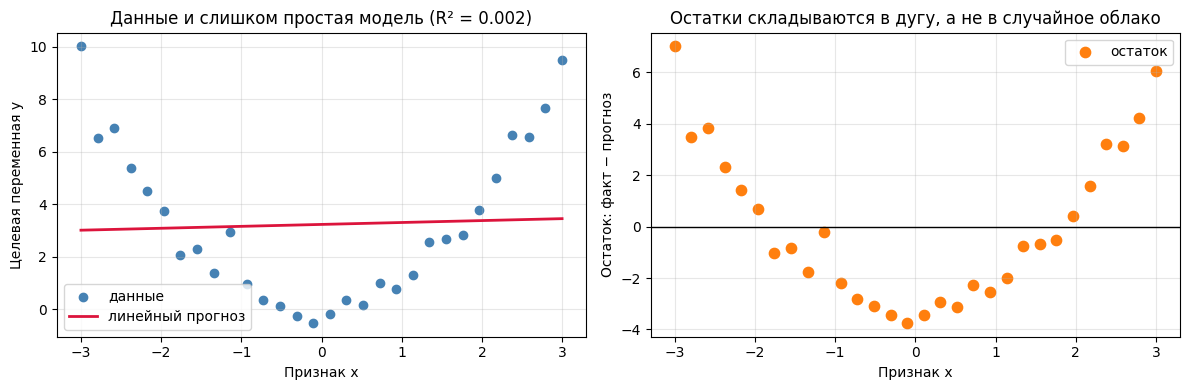


Как читать правую картинку: точки не разбросаны хаотично вокруг нуля,
а выстроились в дугу — по краям модель занижает, в середине завышает.
Такой узор всегда означает: в данных осталась закономерность, которую модель не поймала.


In [13]:
x_curve = np.linspace(-3, 3, 30)
y_curve = x_curve**2 + np.random.default_rng(3).normal(0, 0.5, len(x_curve))

line = LinearRegression().fit(x_curve.reshape(-1, 1), y_curve)
curve_pred = line.predict(x_curve.reshape(-1, 1))
residuals_curve = y_curve - curve_pred

print(f'R² прямой на этих данных: {r2_score(y_curve, curve_pred):.3f}')
print('Почти ноль! То есть прямая здесь не лучше, чем «всегда говорить среднее».')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(x_curve, y_curve, color='steelblue', label='данные')
axes[0].plot(x_curve, curve_pred, color='crimson', linewidth=2, label='линейный прогноз')
axes[0].set_title(f'Данные и слишком простая модель (R² = {r2_score(y_curve, curve_pred):.3f})')
axes[0].set_xlabel('Признак x')
axes[0].set_ylabel('Целевая переменная y')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Остатки точками — так видно форму «облака».
axes[1].scatter(x_curve, residuals_curve, color='tab:orange', s=55, label='остаток')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Остатки складываются в дугу, а не в случайное облако')
axes[1].set_xlabel('Признак x')
axes[1].set_ylabel('Остаток: факт − прогноз')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nКак читать правую картинку: точки не разбросаны хаотично вокруг нуля,')
print('а выстроились в дугу — по краям модель занижает, в середине завышает.')
print('Такой узор всегда означает: в данных осталась закономерность, которую модель не поймала.')


## 11. Линейная регрессия умеет строить кривые *

Слово «линейная» относится не к форме графика, а к тому, **как в формулу входят коэффициенты**. Мы вольны придумать любой новый признак и подать его модели.

Добавим к признаку $x$ ещё один — $x^2$:

$$\hat y=w_1x+w_2x^2+b.$$

По $x$ это парабола, но по коэффициентам $w_1, w_2, b$ — всё та же линейная комбинация. Модель по-прежнему только умножает и складывает; кривизну ей «принесли» готовым признаком.

Так же можно добавить $x^3$, синус, логарифм или произведение двух признаков $x_1x_2$ (последнее как раз даёт то самое «взаимодействие» из п. 10).

В `sklearn` за создание степенных признаков отвечает `PolynomialFeatures`: он берёт столбец $x$ и достраивает к нему $x^2$, $x^3$ и так далее до нужной степени.

Главное — **не увлечься**. Чем больше степеней, тем гибче кривая и тем легче она обовьёт случайный шум вместо закономерности. Что при этом происходит, разберём в следующем разделе.


Было признаков: 1 (это x).  Стало: 2 (это x и x²)

R² прямой:                0.002
R² модели с признаком x²: 0.965
Веса: при x = 0.07, при x² = 1.01
Модель сама нашла, что главный вклад даёт x² с весом около 1 — как в исходной формуле y = x².


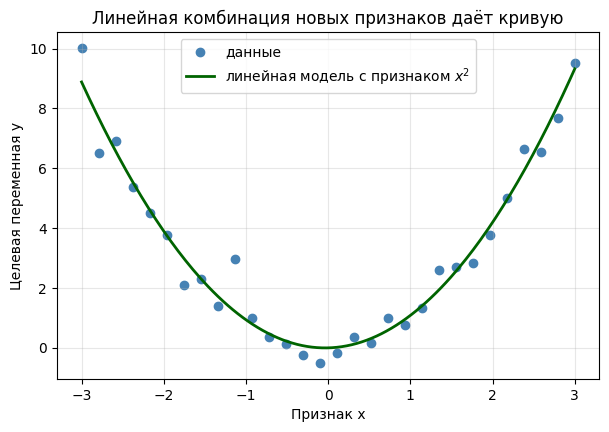

In [14]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_curve_poly = poly.fit_transform(x_curve.reshape(-1, 1))
print('Было признаков: 1 (это x).  Стало:', X_curve_poly.shape[1], '(это x и x²)')

poly_model = LinearRegression()
poly_model.fit(X_curve_poly, y_curve)

print(f'\nR² прямой:                {r2_score(y_curve, curve_pred):.3f}')
print(f'R² модели с признаком x²: {r2_score(y_curve, poly_model.predict(X_curve_poly)):.3f}')
print(f'Веса: при x = {poly_model.coef_[0]:.2f}, при x² = {poly_model.coef_[1]:.2f}')
print('Модель сама нашла, что главный вклад даёт x² с весом около 1 — как в исходной формуле y = x².')

dense = np.linspace(-3, 3, 200).reshape(-1, 1)
dense_poly = poly.transform(dense)

plt.figure(figsize=(7, 4.5))
plt.scatter(x_curve, y_curve, color='steelblue', label='данные')
plt.plot(dense, poly_model.predict(dense_poly), color='darkgreen', linewidth=2,
         label='линейная модель с признаком $x^2$')
plt.xlabel('Признак x')
plt.ylabel('Целевая переменная y')
plt.title('Линейная комбинация новых признаков даёт кривую')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 12. Когда линейная модель переобучается

**Переобучение** — это когда модель отлично отвечает на знакомые примеры и заметно хуже на новых. Она выучила не закономерность, а конкретные точки вместе со случайным шумом.

Линейная регрессия кажется слишком простой, чтобы такое случилось, но и с ней это бывает:

1. **Признаков много, объектов мало.** В пределе, когда признаков столько же, сколько объектов, модель может пройти ровно через все точки — и не понять при этом ничего.
2. **Сложные признаки.** Добавили $x^2$, $x^3$, $x_1x_2$ — и кривая стала настолько гибкой, что обвивает каждое случайное отклонение.
3. **Подглядывание в test.** Если решения о признаках и настройках принимались после того, как вы посмотрели на тест, модель косвенно подстроилась и под него.
4. **Сильно похожие друг на друга признаки.** Модель не может решить, кому из них отдать заслугу, и веса становятся огромными и неустойчивыми. Это отдельный сюжет — **мультиколлинеарность**, о ней п. 16.

Проверим второй пункт на опыте: возьмём 10 обучающих точек, лежащих вдоль прямой с небольшим шумом, и будем наращивать степень.


степень 1: RMSE на обучении = 0.194, RMSE на новых данных = 0.266
степень 2: RMSE на обучении = 0.192, RMSE на новых данных = 0.257
степень 3: RMSE на обучении = 0.166, RMSE на новых данных = 0.255
степень 5: RMSE на обучении = 0.124, RMSE на новых данных = 0.277
степень 9: RMSE на обучении = 0.000, RMSE на новых данных = 0.356


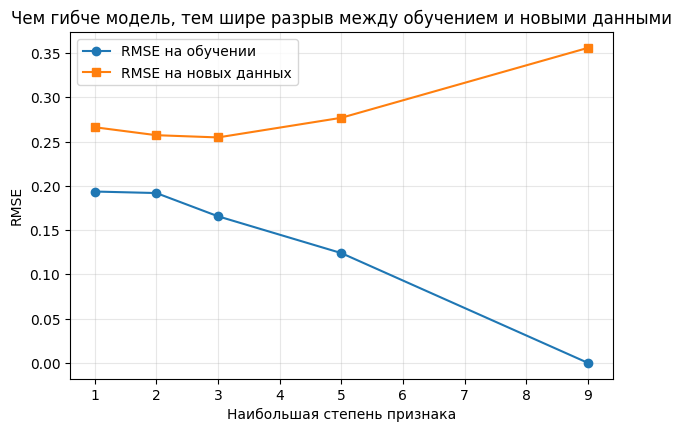


Читаем график: синяя линия падает до нуля — на обучении модель отвечает идеально.
Оранжевая при этом растёт: на новых данных становится ХУЖЕ.
Степень 9 при 10 точках — модель прошла ровно через все и выучила шум.


In [15]:
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(7)
# Настоящая зависимость простая: y = 3x + 2 плюс небольшой шум.
x_train_of = np.linspace(0, 1, 10)
y_train_of = 3 * x_train_of + 2 + rng.normal(0, 0.3, 10)
x_test_of = np.linspace(0, 1, 30)          # новые точки из той же закономерности
y_test_of = 3 * x_test_of + 2 + rng.normal(0, 0.3, 30)

degrees = [1, 2, 3, 5, 9]
rmse_train, rmse_test = [], []
for degree in degrees:
    pf = PolynomialFeatures(degree=degree, include_bias=False)
    flexible = LinearRegression().fit(pf.fit_transform(x_train_of.reshape(-1, 1)), y_train_of)
    tr = np.sqrt(mean_squared_error(y_train_of, flexible.predict(pf.transform(x_train_of.reshape(-1, 1)))))
    te = np.sqrt(mean_squared_error(y_test_of, flexible.predict(pf.transform(x_test_of.reshape(-1, 1)))))
    rmse_train.append(tr)
    rmse_test.append(te)
    print(f'степень {degree}: RMSE на обучении = {tr:.3f}, RMSE на новых данных = {te:.3f}')

plt.figure(figsize=(7, 4.5))
plt.plot(degrees, rmse_train, marker='o', label='RMSE на обучении')
plt.plot(degrees, rmse_test, marker='s', label='RMSE на новых данных')
plt.xlabel('Наибольшая степень признака')
plt.ylabel('RMSE')
plt.title('Чем гибче модель, тем шире разрыв между обучением и новыми данными')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print('\nЧитаем график: синяя линия падает до нуля — на обучении модель отвечает идеально.')
print('Оранжевая при этом растёт: на новых данных становится ХУЖЕ.')
print('Степень 9 при 10 точках — модель прошла ровно через все и выучила шум.')


## 13. Регуляризация: ограничитель сложности *

Когда коэффициенты становятся огромными, модель начинает слишком резко реагировать на маленькие изменения признаков: сдвинули признак на копейку — прогноз прыгнул на миллион. **Регуляризация** борется с этим: к функции потерь добавляется ещё одно слагаемое — **штраф за большие коэффициенты**. Теперь модели выгодно не только точно попадать, но и держать веса скромными.

Штраф можно считать по-разному, и от этого зависит характер модели.

| Модель | Штраф | Название штрафа | Что делает с весами |
|---|---|---|---|
| **Ridge** («ридж», гребневая регрессия) | $\alpha\sum w_j^2$ | **L2** — сумма **квадратов** весов | плавно ужимает все веса, но почти никогда не обнуляет |
| **Lasso** («лассо») | $\alpha\sum\lvert w_j\rvert$ | **L1** — сумма **модулей** весов | может обнулить часть весов начисто, то есть сам выбрасывает ненужные признаки |
| **ElasticNet** («эластик-нет») | смесь L1 и L2 | — | пропорцию задаёт параметр `l1_ratio` |

Обозначения L1 и L2 — это просто номера способов измерять «общую величину» набора чисел: L1 — через модули, L2 — через квадраты.

$\alpha$ (читается «альфа») управляет силой штрафа. Это **гиперпараметр** — число, которое модель не подбирает сама, его задаём мы и подбираем по validation:

- слишком маленькая $\alpha$ — штраф почти не действует, всё как без регуляризации;
- слишком большая $\alpha$ — веса задавлены в ноль, модель недообучается (то есть не улавливает даже настоящую закономерность).

Два практических замечания:

- штраф накладывается только на веса $w_j$, но **не** на смещение $b$: иначе мы запретили бы модели просто сдвинуться по вертикали;
- перед регуляризацией признаки почти всегда нужно привести к одному масштабу — почему, в п. 14.


In [16]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Два почти одинаковых признака: часы подготовки и они же, но записанные
# кем-то другим с погрешностью в ±0.1 часа (например, ученик округлял по-своему).
X_related = np.column_stack([hours, hours + np.array([0.1, -0.1, 0, 0.1, -0.1, 0, 0.1])])
print(f'Корреляция этих двух признаков: {np.corrcoef(X_related[:, 0], X_related[:, 1])[0, 1]:.4f}')
print('То есть это практически один и тот же признак, записанный дважды.\n')

for name, estimator in [
    ('Без штрафа', LinearRegression()),
    ('L2 / Ridge', Ridge(alpha=10)),
    ('L1 / Lasso', Lasso(alpha=1)),
    ('ElasticNet', ElasticNet(alpha=1, l1_ratio=0.5)),
]:
    estimator.fit(X_related, scores)
    r2 = r2_score(scores, estimator.predict(X_related))
    print(f'{name:12}: веса {np.round(estimator.coef_, 2)}  сумма весов {estimator.coef_.sum():5.2f}  R² {r2:.3f}')

print(f'\nНастоящий наклон (одна модель на одном признаке): {w:.2f}')
print('Как читать таблицу:')
print('  1. Без штрафа веса дикие: -6.19 и +13.11. Отрицательный вес у часов подготовки — бессмыслица.')
print('     Но их СУММА 6.92 почти равна настоящему наклону 6.96: модель просто разложила')
print('     один наклон на два слагаемых, и разложила как попало.')
print('  2. Ridge поделил вклад пополам: 2.92 и 2.98 — веса стали скромными и осмысленными.')
print('  3. Lasso обнулил первый признак и оставил только второй: отбор признаков сработал сам.')
print('  4. Заметьте: R² почти не изменился. Скромные веса достались нам почти даром.')
print('\nПример показывает поведение коэффициентов, а не выбирает лучшую модель:')
print('для честного выбора alpha и типа регуляризации нужно сравнивать качество на валидации.')


Корреляция этих двух признаков: 0.9991
То есть это практически один и тот же признак, записанный дважды.

Без штрафа  : веса [-6.19 13.11]  сумма весов  6.92  R² 0.905
L2 / Ridge  : веса [2.92 2.98]  сумма весов  5.91  R² 0.882
L1 / Lasso  : веса [0.  6.7]  сумма весов  6.70  R² 0.903
ElasticNet  : веса [3.14 3.29]  сумма весов  6.43  R² 0.897

Настоящий наклон (одна модель на одном признаке): 6.96
Как читать таблицу:
  1. Без штрафа веса дикие: -6.19 и +13.11. Отрицательный вес у часов подготовки — бессмыслица.
     Но их СУММА 6.92 почти равна настоящему наклону 6.96: модель просто разложила
     один наклон на два слагаемых, и разложила как попало.
  2. Ridge поделил вклад пополам: 2.92 и 2.98 — веса стали скромными и осмысленными.
  3. Lasso обнулил первый признак и оставил только второй: отбор признаков сработал сам.
  4. Заметьте: R² почти не изменился. Скромные веса достались нам почти даром.

Пример показывает поведение коэффициентов, а не выбирает лучшую модель:
для честного в

## 14. Почему важно масштабирование *

Один признак может измеряться десятками (этаж), другой — миллионами (стоимость аренды в рублях). Из-за этого возникают две разные неприятности.

**1. Градиентному спуску становится тяжело.** «Чаша ошибки» из п. 5 растягивается в длинный узкий овраг — вы уже видели такой на графике линий уровня. Шаг, безопасный поперёк оврага, оказывается смехотворно мал вдоль него, и спуск ползёт к минимуму сотнями шагов. После масштабирования чаша становится почти круглой, и путь заметно короче.

**2. Веса перестают быть сравнимыми.** Вес «за 1 м²» и вес «за 1 км» живут в разных единицах, поэтому по их величине нельзя судить, какой признак важнее (ровно эта ловушка ждала нас в п. 9). И регуляризация из п. 13 страдает от того же: штраф $\alpha\sum w_j^2$ бьёт по крупным числам, а крупными они оказываются просто из-за неудачных единиц измерения, а не из-за важности признака.

Лечение — **StandardScaler**. Он преобразует каждый признак так, чтобы среднее стало 0, а стандартное отклонение — 1:

$$z = \frac{x - \text{среднее}}{\text{стандартное отклонение}}$$

*Стандартное отклонение* — это типичный разброс значений вокруг среднего: квадратный корень из среднего квадрата отклонений. После такого преобразования все признаки говорят на одном языке: «на сколько типичных разбросов я отклонился от своего среднего».

Когда масштабирование обязательно, а когда нет:

| Модель | Нужно ли масштабировать |
|---|---|
| `LinearRegression` (прямое решение) | для **прогноза** не обязательно — он не изменится; для **сравнения весов** нужно |
| `Ridge`, `Lasso`, `ElasticNet` | да, обязательно: иначе штраф несправедлив |
| `SGDRegressor` и другие градиентные методы | да, обязательно: иначе спуск будет ползти по оврагу |

⚠️ В настоящей задаче `scaler.fit(...)` вызывают **только на обучающей выборке**, а тест преобразуют уже обученным `scaler.transform(...)`. Иначе среднее и разброс теста просочатся в обучение — это та самая утечка данных из п. 8.


In [17]:
from sklearn.preprocessing import StandardScaler

# Берём квартиры из п. 9 — там признаки в совсем разных единицах: м² и км.
features = apartments[['площадь', 'до_центра_км']]
target = apartments['цена_млн']

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)   # здесь весь набор — только ради демонстрации

print('Средние после StandardScaler:', np.round(features_scaled.mean(axis=0), 6))
print('Стандартные отклонения:      ', np.round(features_scaled.std(axis=0), 6))

raw_model = LinearRegression().fit(features, target)
scaled_model = LinearRegression().fit(features_scaled, target)

print(f'\n{"признак":<16}{"вес БЕЗ масштабирования":>26}{"вес ПОСЛЕ масштабирования":>28}')
for name, raw_w, scaled_w in zip(features.columns, raw_model.coef_, scaled_model.coef_):
    print(f'{name:<16}{raw_w:>26.3f}{scaled_w:>28.3f}')

print(f'\nR² обеих моделей одинаков: {r2_score(target, raw_model.predict(features)):.4f} '
      f'и {r2_score(target, scaled_model.predict(features_scaled)):.4f}')
print('Прогнозы не изменились — изменилась только читаемость весов.')
print()
print('Вот теперь можно сравнивать. БЕЗ масштабирования казалось, что расстояние (0.366)')
print('влияет сильнее площади (0.174). ПОСЛЕ масштабирования видно обратное:')
print('2.96 против 1.28 — площадь важнее более чем вдвое. Первое впечатление было ложным,')
print('его создавали единицы измерения, а не данные.')


Средние после StandardScaler: [0. 0.]
Стандартные отклонения:       [1. 1.]

признак            вес БЕЗ масштабирования   вес ПОСЛЕ масштабирования
площадь                              0.174                       2.965
до_центра_км                        -0.366                      -1.277

R² обеих моделей одинаков: 0.9980 и 0.9980
Прогнозы не изменились — изменилась только читаемость весов.

Вот теперь можно сравнивать. БЕЗ масштабирования казалось, что расстояние (0.366)
влияет сильнее площади (0.174). ПОСЛЕ масштабирования видно обратное:
2.96 против 1.28 — площадь важнее более чем вдвое. Первое впечатление было ложным,
его создавали единицы измерения, а не данные.


## 15. Выбросы и робастные методы *

**Выброс** — наблюдение, стоящее необычно далеко от остальных. Из-за квадратов в MSE (п. 4) одна такая точка весит как десяток обычных и способна ощутимо потянуть всю прямую к себе.

Первое, что нужно сделать с выбросом, — **разобраться, откуда он взялся**. Это опечатка оператора? Сломанный датчик? Или редкий, но совершенно настоящий случай? Автоматически удалять выбросы нельзя: иногда именно они и есть самое интересное в данных.

Как **обнаружить**, что выброс портит модель: обучите её и сравните MAE и MSE. Если MAE выглядит приемлемо, а MSE непропорционально велика — значит, общая ошибка набралась не из множества мелких промахов, а из одного-двух огромных. Это и есть след выброса.

Если необычные точки реальны и удалять их нельзя, берут **робастные** (устойчивые к выбросам) модели:

- **`HuberRegressor`** — «Хьюбер». Работает как обычная регрессия, пока ошибка небольшая, но для крупных ошибок переключается с квадрата на модуль. Большой промах перестаёт весить квадратично, и выброс теряет власть над прямой.
- **`RANSACRegressor`** — от *RANdom SAmple Consensus*, «согласие случайной выборки». Многократно строит прямую по случайной горстке точек и оставляет тот вариант, с которым согласилось больше всего наблюдений. Точки, не попавшие в это большинство, объявляются выбросами и в итоговом обучении не участвуют.

Посмотрим, что делает с прямой одна-единственная плохая точка.


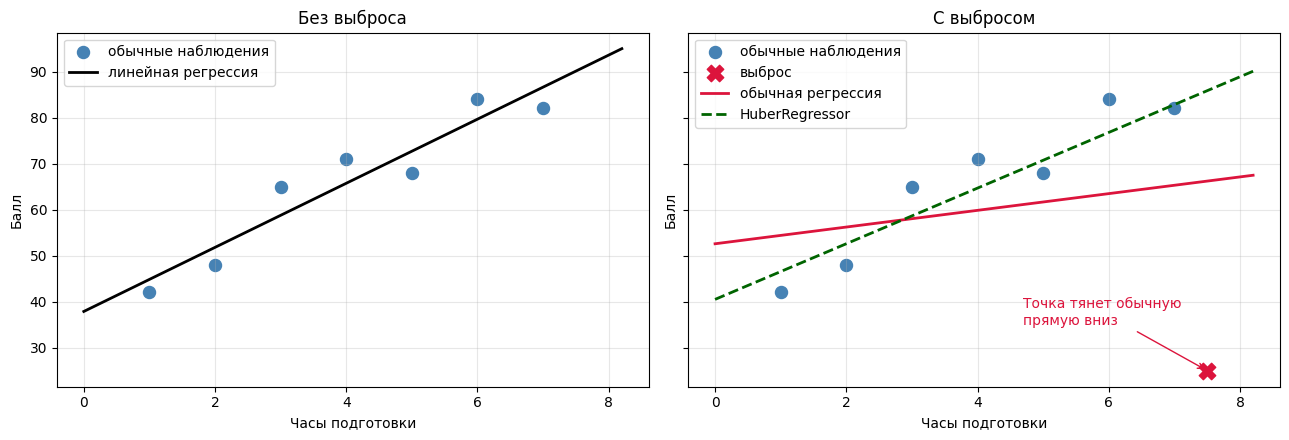

Наклон без выброса:              6.96 балла за час
Наклон обычной регрессии:        1.82 балла за час  <-- почти обнулился!
Наклон HuberRegressor:           6.05 балла за час  <-- почти не пострадал

Одна точка из восьми уронила наклон с 6.96 до 1.82 — обычная модель почти перестала
видеть связь между подготовкой и баллом. Huber устоял: он не даёт одному промаху
весить квадратично.

MAE обычной модели на нормальных точках: 11.76
MAE модели Huber на нормальных точках:   4.65


In [18]:
from sklearn.linear_model import HuberRegressor

x_out = np.append(hours, 7.5)
y_out = np.append(scores, 25)  # необычная точка
ordinary = LinearRegression().fit(x_out.reshape(-1, 1), y_out)
robust = HuberRegressor().fit(x_out.reshape(-1, 1), y_out)

clean = LinearRegression().fit(hours.reshape(-1, 1), scores)
grid = np.linspace(0, 8.2, 100).reshape(-1, 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)

# Слева — закономерность до появления выброса.
axes[0].scatter(hours, scores, s=75, color='steelblue', label='обычные наблюдения')
axes[0].plot(grid, clean.predict(grid), color='black', linewidth=2, label='линейная регрессия')
axes[0].set_title('Без выброса')
axes[0].legend()

# Справа хорошо видно, какую модель выброс тянет к себе.
axes[1].scatter(hours, scores, s=75, color='steelblue', label='обычные наблюдения')
axes[1].scatter([7.5], [25], s=140, color='crimson', marker='X', label='выброс')
axes[1].plot(grid, ordinary.predict(grid), color='crimson', linewidth=2, label='обычная регрессия')
axes[1].plot(grid, robust.predict(grid), color='darkgreen', linewidth=2, linestyle='--', label='HuberRegressor')
axes[1].annotate('Точка тянет обычную\nпрямую вниз', xy=(7.5, 25), xytext=(4.7, 35),
                 arrowprops={'arrowstyle': '->', 'color': 'crimson'}, color='crimson')
axes[1].set_title('С выбросом')
axes[1].legend(loc='upper left')

for ax in axes:
    ax.set_xlabel('Часы подготовки')
    ax.set_ylabel('Балл')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Наклон без выброса:              {clean.coef_[0]:.2f} балла за час')
print(f'Наклон обычной регрессии:        {ordinary.coef_[0]:.2f} балла за час  <-- почти обнулился!')
print(f'Наклон HuberRegressor:           {robust.coef_[0]:.2f} балла за час  <-- почти не пострадал')
print()
print('Одна точка из восьми уронила наклон с 6.96 до 1.82 — обычная модель почти перестала')
print('видеть связь между подготовкой и баллом. Huber устоял: он не даёт одному промаху')
print('весить квадратично.')
print()
print(f'MAE обычной модели на нормальных точках: {mean_absolute_error(scores, ordinary.predict(X)):.2f}')
print(f'MAE модели Huber на нормальных точках:   {mean_absolute_error(scores, robust.predict(X)):.2f}')


## 16. Мультиколлинеарность *

**Мультиколлинеарность** возникает, когда признаки сильно связаны друг с другом: например, длина в метрах и та же длина в сантиметрах.

Как заметить:

- посмотреть корреляции числовых признаков;
- построить диаграммы рассеяния;
- проверить, сильно ли меняются веса при небольшом изменении обучающих данных.

Почему это плохо: прогноз внутри знакомого диапазона может оставаться хорошим, но модель не понимает, как «поделить заслугу» между похожими признаками. Поэтому коэффициенты становятся нестабильными, иногда большими и с неожиданными знаками. Особенно осторожно нужно интерпретировать веса и прогнозировать необычные комбинации признаков.

Помогают:

- удаление признаков, дублирующих один и тот же смысл;
- объединение признаков;
- Ridge-регуляризация (Lasso может оставить один из нескольких похожих признаков, но выбор между ними бывает нестабильным).


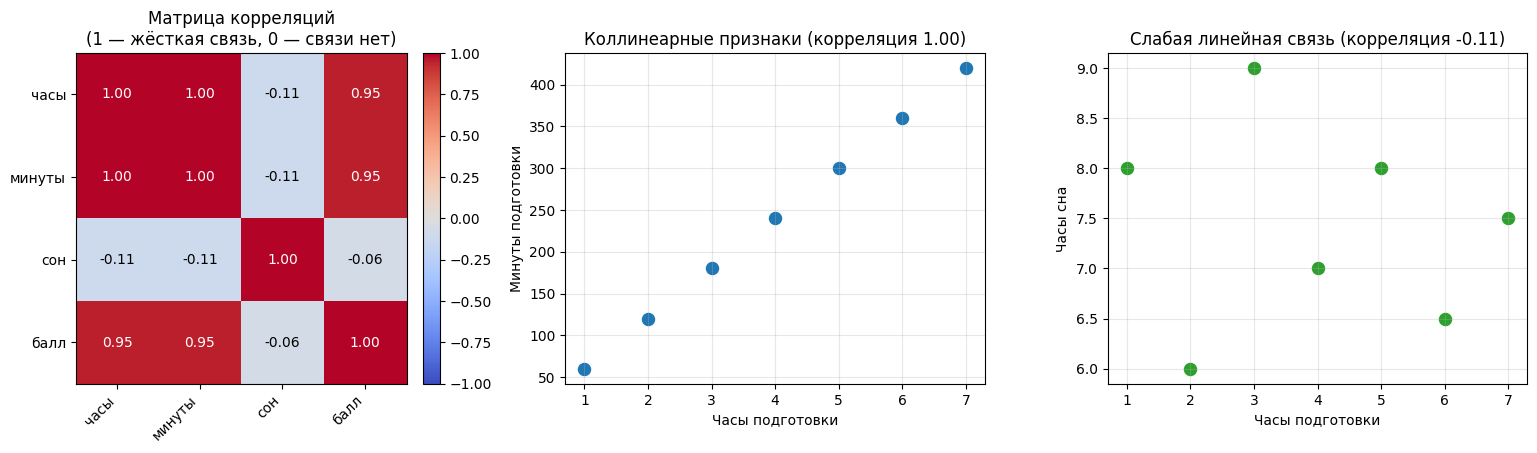

Слегка меняем баллы (в пределах ±1) и каждый раз переобучаем модель
на двух почти одинаковых признаках из п. 13:

  попытка 1: веса [-9.85 16.88]   сумма 7.02
  попытка 2: веса [-9.62 16.33]   сумма 6.71
  попытка 3: веса [-2.93 10.14]   сумма 7.21
  попытка 4: веса [-10.88  17.52]   сумма 6.64

Веса скачут от -2.9 до -10.9 и от 10.1 до 17.5 — при том, что данные почти не менялись!
А сумма весов всё время держится около 6.9. Модель уверена в ОБЩЕМ наклоне
и совершенно не уверена, как поделить его между двумя близнецами.
Именно поэтому такие веса нельзя интерпретировать.

То же самое, но с Ridge(alpha=10):
  попытка 1: веса [2.97 3.05]   сумма 6.01
  попытка 2: веса [2.84 2.91]   сумма 5.75
  попытка 3: веса [3.05 3.09]   сумма 6.14
  попытка 4: веса [2.81 2.89]   сумма 5.69
Вот теперь веса стоят на месте — регуляризация вернула им устойчивость.


In [19]:
multi_features = pd.DataFrame({
    'часы': hours,
    'минуты': hours * 60,                # тот же признак в других единицах
    'сон': [8, 6, 9, 7, 8, 6.5, 7.5],    # действительно отдельный признак
    'балл': scores,
})
corr = multi_features.corr()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Корреляция измеряет силу ЛИНЕЙНОЙ связи и лежит от -1 до +1.
image = axes[0].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
axes[0].set_yticks(range(len(corr.index)), corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        axes[0].text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                     color='white' if abs(corr.iloc[i, j]) > 0.65 else 'black')
axes[0].set_title('Матрица корреляций\n(1 — жёсткая связь, 0 — связи нет)')
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].scatter(multi_features['часы'], multi_features['минуты'], s=75)
axes[1].set_title(f'Коллинеарные признаки (корреляция {corr.loc["часы", "минуты"]:.2f})')
axes[1].set_xlabel('Часы подготовки')
axes[1].set_ylabel('Минуты подготовки')
axes[1].grid(alpha=0.3)

axes[2].scatter(multi_features['часы'], multi_features['сон'], s=75, color='tab:green')
axes[2].set_title(f'Слабая линейная связь (корреляция {corr.loc["часы", "сон"]:.2f})')
axes[2].set_xlabel('Часы подготовки')
axes[2].set_ylabel('Часы сна')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Третий способ диагностики из списка выше: чуть-чуть трясём данные и смотрим на веса.
print('Слегка меняем баллы (в пределах ±1) и каждый раз переобучаем модель')
print('на двух почти одинаковых признаках из п. 13:\n')
rng_shake = np.random.default_rng(0)
for attempt in range(4):
    y_shaken = scores + rng_shake.normal(0, 1.0, len(scores))
    coefs = LinearRegression().fit(X_related, y_shaken).coef_
    print(f'  попытка {attempt + 1}: веса {np.round(coefs, 2)}   сумма {coefs.sum():.2f}')

print('\nВеса скачут от -2.9 до -10.9 и от 10.1 до 17.5 — при том, что данные почти не менялись!')
print('А сумма весов всё время держится около 6.9. Модель уверена в ОБЩЕМ наклоне')
print('и совершенно не уверена, как поделить его между двумя близнецами.')
print('Именно поэтому такие веса нельзя интерпретировать.')

print('\nТо же самое, но с Ridge(alpha=10):')
rng_shake = np.random.default_rng(0)
for attempt in range(4):
    y_shaken = scores + rng_shake.normal(0, 1.0, len(scores))
    coefs = Ridge(alpha=10).fit(X_related, y_shaken).coef_
    print(f'  попытка {attempt + 1}: веса {np.round(coefs, 2)}   сумма {coefs.sum():.2f}')
print('Вот теперь веса стоят на месте — регуляризация вернула им устойчивость.')


## 17. Алгоритм работы над задачей регрессии

Сведём всё занятие в один порядок действий. В скобках — куда вернуться, если шаг непонятен.

1. Понять, какое число предсказываем, в какой момент и зачем *(п. 2)*.
2. Отделить test подходящим способом **до** любого исследования и настройки *(п. 8)*.
3. Исследовать только train: пропуски, распределения, выбросы, связи признаков *(пп. 15, 16)*.
4. Выбрать метрику под смысл задачи и построить константный baseline *(пп. 6, 7)*.
5. Обучить простую линейную регрессию и посмотреть на её метрики *(пп. 3, 9)*.
6. По validation или кросс-валидации подобрать признаки, масштабирование и регуляризацию *(пп. 8, 11, 13, 14)*.
7. Построить график остатков и разобрать отдельные крупные ошибки *(п. 10)*.
8. Зафиксировать выбранный процесс и переобучить его на train + validation.
9. Один раз проверить качество на test и честно описать ограничения *(п. 8)*.

Главное правило всего списка: **шаг 9 выполняется ровно один раз**. Если после него хочется что-то поменять — значит, менять надо было на шаге 6.


## Итог занятия

Сегодня научились:
- отличать **регрессию** от классификации и объяснять прогноз линейной модели $\hat y = w\cdot x + b$;
- читать **MAE**, **MSE**, **RMSE** и **$R^2$** и сравнивать модель с baseline «всегда среднее»;
- делить данные на **train / validation / test** и не подбирать сложность по test;
- добавлять признаки (в том числе $x^2$), сохраняя модель линейной по коэффициентам;
- ограничивать сложность **регуляризацией** (Ridge / Lasso), помнить про **масштабирование**, выбросы и **мультиколлинеарность**.

**Главная мысль:** «линейная» — про коэффициенты, а не про форму графика. Хорошая ошибка относительна: всегда смотрите baseline и **новые** данные, а не только train.
